# 🕵️ Dataset Lie Detector: Is Your Data Lying to You?

**A reusable toolkit that tells you, in minutes, whether a dataset can be trusted for machine learning. Tested here on 5.9 million rows of banking data.**

Before you spend a weekend tuning XGBoost on a dataset, it is worth asking one simple question:

> *Is there actually anything here for a model to learn?*

Most notebooks skip that question. This one answers it, and gives you a tool to answer it for **any** dataset.

**🔗 GitHub:** [https://github.com/CollinsLemeke/dataset-lie-detector](https://github.com/CollinsLemeke/dataset-lie-detector) &nbsp;|&nbsp; **Author:** Collins Lemeke

---

### TL;DR

- **All three ML labels are noise.** Fraud, late payment and loan default models score **ROC AUC 0.50 to 0.52**, the same as models trained on randomly shuffled labels. In plain English: coin flips.
- **The detector is proven, not just pessimistic.** It scores **0.99** on a real medical dataset and **0.82** on a realistic fraud pattern planted into the *same* 3 million transactions, and marks both PASS.
- **The tables look clean but do not connect.** Every ID is valid and there are zero missing values, yet **over 99.99%** of cards are linked to an account owned by someone else, **47%** of loan payments happen before the loan starts, and **14%** of customers joined the bank as children.
- **Trust Score: 35/100.** Great for SQL and Power BI practice. Not suitable for training ML models.

---

### What's inside

1. **The toolkit**: one class, `LieDetector`, that you can copy into any project
2. **Check 1, Signal**: do the labels carry a real pattern, or are they coin flips?
3. **Proof the detector works**: it must say PASS on real signal, not just FAIL everything
4. **Check 2, Integrity**: do the tables link together correctly?
5. **Check 3, Time**: do events happen in a possible order?
6. **Check 4, Plausibility**: do real-world rules and relationships hold?
7. **The verdict**: a scorecard and a Trust Score out of 100
8. **Use it on your own data** in 5 lines

## A note on fairness

This dataset's description says it was built for **SQL, Python and Power BI practice**, and for that purpose it is clean, large and well organised (zero missing values across 5.9M rows). Nothing here is a criticism of the creator.

The point is narrower: **if you plan to train ML models on it, you should know what the labels can and cannot support.** The same checks apply to any dataset you find online, including real ones.

## 1. The toolkit

The cell below writes `lie_detector.py` to disk and imports it. It is self-contained (pandas, numpy, scipy, scikit-learn, all preinstalled on Kaggle).

**How the key test works, in plain English:**

- Train a model to predict the label and measure its ROC AUC (0.5 = coin flip, 1.0 = perfect).
- Then **shuffle the labels randomly** and train the same model again, several times. This tells us what "pure luck" looks like.
- If the real model is not clearly better than the shuffled ones, **the labels contain no learnable pattern.**

This is called a *permutation test*, and it is one of the most honest checks in machine learning.

In [1]:
%%writefile lie_detector.py
"""
Dataset Lie Detector
====================

A small, reusable toolkit that tells you whether a dataset can be trusted
before you spend hours modelling it.

It answers four questions:

1. Signal:      Do the labels carry any learnable pattern, or are they noise?
2. Integrity:   Do the tables link together the way they claim to?
3. Time:        Do events happen in a possible order?
4. Plausibility: Do business rules and expected relationships hold?

Every check adds a finding (PASS / WARN / FAIL) to a scorecard, and the
scorecard rolls up into a single Trust Score out of 100.

Author: Collins Lemeke (github.com/CollinsLemeke, kaggle.com/collinslemeke)
License: MIT
"""

from __future__ import annotations

from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

__version__ = "1.0.0"

PASS, WARN, FAIL = "PASS", "WARN", "FAIL"
_ICON = {PASS: "✅", WARN: "⚠️", FAIL: "❌"}
_POINTS = {PASS: 1.0, WARN: 0.5, FAIL: 0.0}


@dataclass
class Finding:
    group: str      # Signal / Integrity / Time / Plausibility
    check: str      # short name of the check
    status: str     # PASS / WARN / FAIL
    metric: str     # the headline number, as text
    detail: str     # one plain-English sentence


class LieDetector:
    """Collects checks on a dataset and produces a scorecard.

    Parameters
    ----------
    name : str
        Name shown in the report.
    warn_rate, fail_rate : float
        Thresholds for rate-based checks (share of rows breaking a rule).
        Default: above 0.1% is a warning, above 5% is a failure.
    random_state : int
        Seed for sampling, cross-validation and label shuffling.
    """

    def __init__(self, name: str = "dataset", warn_rate: float = 0.001,
                 fail_rate: float = 0.05, random_state: int = 42):
        self.name = name
        self.warn_rate = warn_rate
        self.fail_rate = fail_rate
        self.random_state = random_state
        self.findings: list[Finding] = []
        self.signal_results: list[dict] = []

    # ------------------------------------------------------------------ utils
    def _add(self, group, check, status, metric, detail, verbose=True):
        f = Finding(group, check, status, metric, detail)
        self.findings.append(f)
        if verbose:
            print(f"{_ICON[status]} [{group}] {check}: {metric}  |  {detail}")
        return f

    @staticmethod
    def _pct(rate):
        if 0 < rate < 0.0001:
            return "<0.01%"
        if 0.9999 < rate < 1:
            return ">99.99%"
        return f"{rate:.2%}"

    def _rate_status(self, rate):
        if rate > self.fail_rate:
            return FAIL
        if rate > self.warn_rate:
            return WARN
        return PASS

    @staticmethod
    def _prepare_features(df, features):
        X = df[features].copy()
        for c in X.columns:
            if pd.api.types.is_datetime64_any_dtype(X[c]):
                X[c] = X[c].astype("int64") // 86_400_000_000_000  # days since epoch
            elif pd.api.types.is_bool_dtype(X[c]):
                X[c] = X[c].astype(int)
            elif not pd.api.types.is_numeric_dtype(X[c]):
                # text or category columns (works for both old object and new str dtypes)
                X[c] = X[c].astype(str).astype("category")
        return X

    def _cv_auc(self, X, y, cv, seed):
        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
        scores = []
        for tr, te in skf.split(X, y):
            model = HistGradientBoostingClassifier(
                max_iter=150, learning_rate=0.1, categorical_features="from_dtype",
                random_state=seed)
            model.fit(X.iloc[tr], y.iloc[tr])
            scores.append(roc_auc_score(y.iloc[te], model.predict_proba(X.iloc[te])[:, 1]))
        return float(np.mean(scores))

    # ============================================================ 1. SIGNAL
    def label_signal(self, df: pd.DataFrame, target: str, features: list[str] | None = None,
                     sample: int = 200_000, n_permutations: int = 5, cv: int = 3,
                     name: str | None = None, verbose: bool = True) -> dict:
        """Can a model learn the target at all?

        Trains a gradient-boosted model with cross-validation and compares its
        ROC AUC against the same model trained on SHUFFLED labels (the "null").
        If the real AUC is not clearly above the null, the labels are noise.

        Verdict: PASS if AUC >= 0.60 and it beats the null by > 3 standard
        deviations; FAIL if AUC < 0.55 or it does not beat the null; WARN between.
        """
        name = name or target
        y_all = df[target]
        if y_all.nunique() != 2:
            raise ValueError("label_signal supports binary targets only")
        if features is None:
            features = [c for c in df.columns
                        if c != target and not c.lower().endswith("_id") and c.lower() != "id"]

        rng = np.random.RandomState(self.random_state)
        if len(df) > sample:
            # stratified sample keeps the positive rate intact
            frac = sample / len(df)
            idx = np.concatenate([
                rng.choice(g.index.values, size=max(1, int(round(len(g) * frac))), replace=False)
                for _, g in df.groupby(target)])
            data = df.loc[idx]
        else:
            data = df
        X = self._prepare_features(data, features)
        y = data[target].astype(int).reset_index(drop=True)
        X = X.reset_index(drop=True)

        auc = self._cv_auc(X, y, cv, self.random_state)
        null = []
        for i in range(n_permutations):
            y_shuffled = pd.Series(rng.permutation(y.values))
            null.append(self._cv_auc(X, y_shuffled, cv, self.random_state + i + 1))
        null = np.array(null)
        null_mean, null_std = float(null.mean()), float(max(null.std(ddof=1), 1e-3))
        z = (auc - null_mean) / null_std

        if auc >= 0.60 and z > 3:
            status, verdict = PASS, "the labels carry a learnable pattern"
        elif auc < 0.55 or z <= 3:
            status, verdict = FAIL, "no better than shuffled labels, so the labels look like noise"
        else:
            status, verdict = WARN, "weak signal, model with care"

        res = dict(name=name, target=target, auc=auc, null_mean=null_mean,
                   null_std=null_std, null=null.tolist(), z=z, n_rows=len(y),
                   positive_rate=float(y.mean()), n_features=len(features), status=status)
        self.signal_results.append(res)
        self._add("Signal", f"Label signal: {name}", status,
                  f"AUC {auc:.3f} vs shuffled {null_mean:.3f}",
                  f"{verdict} ({len(features)} features, {len(y):,} rows).", verbose)
        return res

    def label_spread(self, df: pd.DataFrame, target: str, by: str,
                     verbose: bool = True) -> pd.DataFrame:
        """Does the target rate change across groups of a column?

        Returns the rate per group and runs a chi-square test. Real labels
        usually vary across at least some groups; flat rates are a red flag.
        """
        table = (df.groupby(by, observed=True)[target]
                   .agg(rate="mean", n="size").sort_values("rate", ascending=False))
        ct = pd.crosstab(df[by], df[target])
        chi2, p, _, _ = stats.chi2_contingency(ct)
        # Cramer's V: effect size, 0 = no association, 1 = perfect
        n = ct.values.sum()
        v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
        status = PASS if (p < 0.01 and v >= 0.02) else WARN
        spread = table["rate"].max() - table["rate"].min()
        self._add("Signal", f"{target} by {by}", status,
                  f"Cramer's V {v:.3f}, p={p:.2g}",
                  f"rate ranges {table['rate'].min():.2%} to {table['rate'].max():.2%} "
                  f"(spread {spread:.2%}).", verbose)
        return table

    # ========================================================= 2. INTEGRITY
    def foreign_key(self, child: pd.DataFrame, key: str, parent: pd.DataFrame,
                    parent_key: str | None = None, name: str | None = None,
                    verbose: bool = True) -> float:
        """Share of child rows whose key does not exist in the parent table."""
        parent_key = parent_key or key
        rate = float((~child[key].isin(parent[parent_key])).mean())
        self._add("Integrity", name or f"Foreign key {key}", self._rate_status(rate),
                  f"{self._pct(rate)} orphans",
                  "every ID points to a real record." if rate == 0 else "rows point to a record that does not exist.", verbose)
        return rate

    def agreement(self, name: str, left: pd.Series, right: pd.Series,
                  detail: str = "", verbose: bool = True) -> float:
        """Two columns that should always match (e.g. the owner of a card vs
        the owner of the account it is linked to). Returns the mismatch rate."""
        rate = float((left.values != right.values).mean())
        self._add("Integrity", name, self._rate_status(rate), f"{self._pct(rate)} mismatched",
                  "values agree." if rate == 0 else (detail or "values that should agree do not."), verbose)
        return rate

    def duplicates(self, df: pd.DataFrame, subset: list[str] | None = None,
                   name: str = "Duplicate rows", verbose: bool = True) -> float:
        rate = float(df.duplicated(subset=subset).mean())
        self._add("Integrity", name, self._rate_status(rate), f"{self._pct(rate)} duplicated",
                  "no repeated rows." if rate == 0 else "identical rows repeated.", verbose)
        return rate

    # ============================================================== 3. TIME
    def date_order(self, name: str, earlier: pd.Series, later: pd.Series,
                   detail: str = "", verbose: bool = True) -> float:
        """Share of rows where `later` happens before `earlier`."""
        e, l = pd.to_datetime(earlier).values, pd.to_datetime(later).values
        rate = float((l < e).mean())
        self._add("Time", name, self._rate_status(rate), f"{self._pct(rate)} impossible",
                  "events happen in a possible order." if rate == 0 else (detail or "events happen in the wrong order."), verbose)
        return rate

    # ====================================================== 4. PLAUSIBILITY
    def rule(self, name: str, violations: pd.Series, detail: str = "",
             verbose: bool = True) -> float:
        """Any custom business rule. Pass a boolean Series that is True where
        the rule is BROKEN."""
        rate = float(pd.Series(violations).mean())
        self._add("Plausibility", name, self._rate_status(rate), f"{self._pct(rate)} break the rule",
                  "rule holds." if rate == 0 else (detail or "rows that break a real-world rule."), verbose)
        return rate

    def expected_relationship(self, name: str, x: pd.Series, y: pd.Series,
                              direction: str = "positive", min_abs: float = 0.05,
                              detail: str = "", verbose: bool = True) -> float:
        """A relationship you would expect in real life (e.g. higher credit
        score -> lower interest rate). Uses Spearman correlation. WARN, not
        FAIL, because real data can legitimately surprise you."""
        rho, p = stats.spearmanr(x, y, nan_policy="omit")
        ok = (rho >= min_abs) if direction == "positive" else (rho <= -min_abs)
        status = PASS if (ok and p < 0.01) else WARN
        self._add("Plausibility", name, status, f"Spearman {rho:+.3f}",
                  detail or f"expected a {direction} relationship.", verbose)
        return float(rho)

    # ============================================================ REPORTING
    def trust_score(self) -> float:
        """0 to 100. PASS = full marks, WARN = half, FAIL = zero. Signal checks
        count double, because labels are what a model learns from."""
        if not self.findings:
            return float("nan")
        w = np.array([2.0 if f.group == "Signal" and f.check.startswith("Label signal") else 1.0
                      for f in self.findings])
        pts = np.array([_POINTS[f.status] for f in self.findings])
        return float(100 * (w * pts).sum() / w.sum())

    def report(self) -> pd.DataFrame:
        df = pd.DataFrame([asdict(f) for f in self.findings])
        if df.empty:
            return df
        df.insert(2, "result", df["status"].map(lambda s: f"{_ICON[s]} {s}"))
        return df.drop(columns="status")

    def summary(self) -> str:
        counts = pd.Series([f.status for f in self.findings]).value_counts()
        score = self.trust_score()
        verdict = ("Trustworthy for ML" if score >= 80 else
                   "Use with caution" if score >= 50 else
                   "Not suitable for ML as-is")
        return (f"{self.name}: Trust Score {score:.0f}/100 ({verdict}) | "
                f"{counts.get(PASS, 0)} pass, {counts.get(WARN, 0)} warn, {counts.get(FAIL, 0)} fail")

Overwriting lie_detector.py


In [2]:
import glob, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from lie_detector import LieDetector, PASS, WARN, FAIL

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

# Chart style: quiet axes, one accent colour, status colours reserved for verdicts
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"
STATUS = {PASS: "#0ca30c", WARN: "#fab219", FAIL: "#d03b3b"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

## 2. Load the data

Ten tables, linked by ID columns, like a real bank database. The loader finds the files wherever Kaggle mounts them.

In [3]:
hits = glob.glob("/kaggle/input/**/card_transactions.csv", recursive=True)
DATA_DIR = os.path.dirname(hits[0]) if hits else os.environ.get("BANK_DATA", "./data")
print("Reading from:", DATA_DIR if hits else "local ./data folder")

dates = {
    "customers": ["date_of_birth", "join_date"], "accounts": ["open_date"],
    "cards": ["issue_date", "expiry_date"], "card_transactions": ["txn_date"],
    "transactions": ["txn_date"], "loans": ["start_date"], "loan_payments": ["payment_date"],
    "support_tickets": ["date_opened", "date_resolved"], "branches": ["opened_date"],
    "employees": ["hire_date"],
}
T = {name: pd.read_csv(f"{DATA_DIR}/{name}.csv", parse_dates=cols) for name, cols in dates.items()}

overview = pd.DataFrame({
    "rows": {k: len(v) for k, v in T.items()},
    "columns": {k: v.shape[1] for k, v in T.items()},
    "missing values": {k: int(v.isna().sum().sum()) for k, v in T.items()},
}).sort_values("rows", ascending=False)
display(overview)
print(f"Total rows: {overview['rows'].sum():,}")

Reading from: local ./data folder


,rows,columns,missing values
card_transactions,3000000,6,0
transactions,2000000,7,0
loan_payments,600000,7,0
accounts,95000,7,0
cards,65000,8,0
customers,60000,12,0
support_tickets,25000,7,0
loans,22000,9,0
employees,1800,6,0
branches,150,6,0


Total rows: 5,868,950


In [4]:
ld = LieDetector(name="Banking Transactions Dataset")
cu, ac, ca, ct, tx = T["customers"], T["accounts"], T["cards"], T["card_transactions"], T["transactions"]
lo, lp, st, br = T["loans"], T["loan_payments"], T["support_tickets"], T["branches"]

## 3. Check 1: Do the labels carry any signal?

The dataset has three natural ML targets:

| Target | Question a model would answer |
|---|---|
| `is_fraud` | Is this card transaction fraudulent? |
| `late_payment_flag` | Will this loan payment be late? |
| `status = Defaulted / Written Off` | Will this loan go bad? |

For each, I build the features a data scientist would reasonably use, joining tables together, then run the permutation test.

### 3a. Card fraud

In [5]:
fraud = (ct.merge(ca[["card_id", "customer_id", "card_type", "credit_limit", "issue_date"]], on="card_id")
           .merge(cu[["customer_id", "annual_income", "credit_score", "occupation", "date_of_birth"]], on="customer_id")
           .sort_values(["card_id", "txn_date"]))

# Classic fraud features: how unusual is this spend for this card, and how fast are transactions coming?
fraud["amount_vs_card_avg"] = fraud["amount"] / fraud.groupby("card_id")["amount"].transform("mean")
fraud["days_since_last_txn"] = fraud.groupby("card_id")["txn_date"].diff().dt.days
fraud["card_age_days"] = (fraud["txn_date"] - fraud["issue_date"]).dt.days
fraud["customer_age"] = (fraud["txn_date"] - fraud["date_of_birth"]).dt.days / 365.25
fraud["day_of_week"] = fraud["txn_date"].dt.dayofweek
fraud["month"] = fraud["txn_date"].dt.month

FRAUD_FEATURES = ["amount", "merchant_category", "card_type", "credit_limit", "amount_vs_card_avg",
                  "days_since_last_txn", "card_age_days", "annual_income", "credit_score",
                  "occupation", "customer_age", "day_of_week", "month"]
r_fraud = ld.label_signal(fraud, "is_fraud", FRAUD_FEATURES, name="Card fraud")

❌ [Signal] Label signal: Card fraud: AUC 0.513 vs shuffled 0.498  |  no better than shuffled labels, so the labels look like noise (13 features, 200,000 rows).


### 3b. Late loan payments and loan defaults

In [6]:
loans = lo.merge(cu[["customer_id", "annual_income", "credit_score", "occupation"]], on="customer_id")
pay = lp.merge(loans[["loan_id", "loan_type", "loan_amount", "interest_rate", "term_months",
                      "annual_income", "credit_score", "occupation"]], on="loan_id")

LATE_FEATURES = ["amount_paid", "loan_type", "loan_amount", "interest_rate", "term_months",
                 "annual_income", "credit_score", "occupation"]
r_late = ld.label_signal(pay, "late_payment_flag", LATE_FEATURES, name="Late payment")

# Loan level: did the loan go bad? Includes the loan's own late-payment history, a strong real-world predictor
loans["late_rate"] = loans["loan_id"].map(lp.groupby("loan_id")["late_payment_flag"].mean())
loans["bad_loan"] = loans["status"].isin(["Defaulted", "Written Off"]).astype(int)
DEFAULT_FEATURES = ["loan_type", "loan_amount", "interest_rate", "term_months",
                    "annual_income", "credit_score", "occupation", "late_rate"]
r_default = ld.label_signal(loans, "bad_loan", DEFAULT_FEATURES, name="Loan default")

❌ [Signal] Label signal: Late payment: AUC 0.499 vs shuffled 0.499  |  no better than shuffled labels, so the labels look like noise (8 features, 200,000 rows).


❌ [Signal] Label signal: Loan default: AUC 0.516 vs shuffled 0.494  |  no better than shuffled labels, so the labels look like noise (8 features, 22,000 rows).


## 4. Proof the detector works (positive controls)

A detector that says FAIL to everything is useless. So before trusting the result above, I test it on two cases where I **know** a real pattern exists:

1. **Breast cancer diagnosis** (scikit-learn's built-in, real clinical dataset).
2. **A planted pattern**: I take the *same* bank card transactions and create a new fraud label that follows realistic rules (unusually large spend for that card, travel and shopping merchants, bigger amounts), with randomness added. Same rows, same features, only the label changes.

If the detector is honest, both should PASS. These go into a separate detector so they don't affect the bank's score.

In [7]:
from sklearn.datasets import load_breast_cancer

controls = LieDetector(name="Positive controls")
r_cancer = controls.label_signal(load_breast_cancer(as_frame=True).frame, "target", name="Breast cancer (real)")

rng = np.random.RandomState(0)
logit = (-6.0
         + 2.0 * (fraud["amount_vs_card_avg"] > 2.5)
         + 1.5 * fraud["merchant_category"].isin(["Travel", "Shopping"])
         + 0.0002 * fraud["amount"])
fraud["planted_fraud"] = (rng.rand(len(fraud)) < 1 / (1 + np.exp(-logit))).astype(int)
print(f"Planted fraud rate: {fraud['planted_fraud'].mean():.2%}")
r_planted = controls.label_signal(fraud, "planted_fraud", FRAUD_FEATURES, name="Planted fraud pattern")

✅ [Signal] Label signal: Breast cancer (real): AUC 0.990 vs shuffled 0.487  |  the labels carry a learnable pattern (30 features, 569 rows).


Planted fraud rate: 1.15%


✅ [Signal] Label signal: Planted fraud pattern: AUC 0.822 vs shuffled 0.497  |  the labels carry a learnable pattern (13 features, 200,000 rows).


### The picture: real model vs pure luck

Each row is one label. The **grey band** is the range a model reaches with shuffled (meaningless) labels. The **dot** is the real model. A trustworthy label sits far to the right of its grey band.

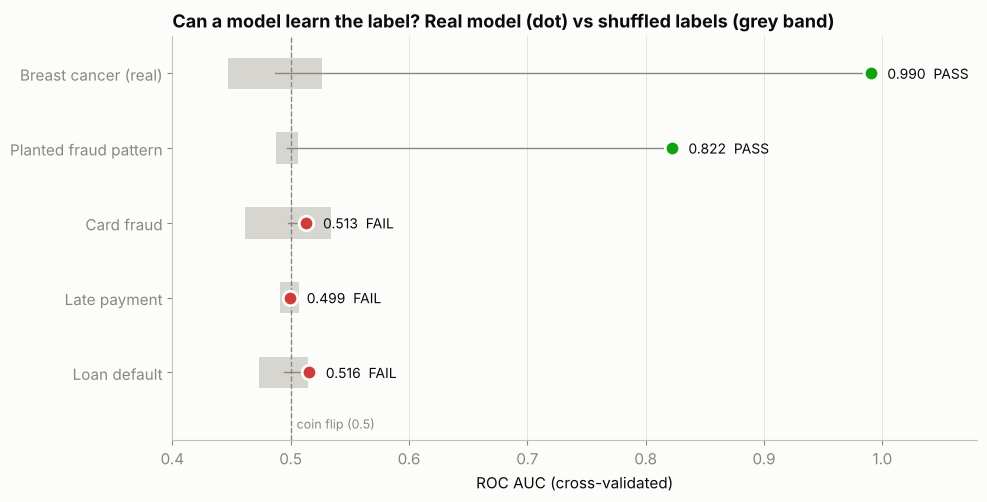

In [8]:
def plot_signal(results):
    results = results[::-1]
    fig, ax = plt.subplots(figsize=(10, 0.75 * len(results) + 1.4))
    for i, r in enumerate(results):
        lo_, hi_ = r["null_mean"] - 3 * r["null_std"], r["null_mean"] + 3 * r["null_std"]
        ax.barh(i, hi_ - lo_, left=lo_, height=0.42, color="#d6d5cf", zorder=1)
        ax.plot([r["null_mean"], r["auc"]], [i, i], color=MUTED, lw=1, zorder=2)
        ax.scatter(r["auc"], i, s=110, color=STATUS[r["status"]], edgecolor=SURFACE, linewidth=2, zorder=3)
        ax.annotate(f"{r['auc']:.3f}  {r['status']}", (r["auc"], i), xytext=(12, -4),
                    textcoords="offset points", fontsize=10, color=INK)
    ax.axvline(0.5, color=MUTED, ls="--", lw=1)
    ax.set_ylim(-0.9, len(results) - 0.5)
    ax.text(0.505, -0.75, "coin flip (0.5)", color=MUTED, fontsize=9)
    ax.set_yticks(range(len(results)), [r["name"] for r in results])
    ax.set_xlim(0.4, 1.08)
    ax.set_xlabel("ROC AUC (cross-validated)")
    ax.set_title("Can a model learn the label? Real model (dot) vs shuffled labels (grey band)")
    ax.grid(axis="y", visible=False)
    plt.tight_layout(); plt.show()

plot_signal(controls.signal_results + ld.signal_results)

### Look closer: noise vs signal, side by side

Here is the same comparison without any model. On the left, the dataset's fraud rate by merchant category. On the right, the planted (realistic) fraud label on the **exact same transactions**.

Real fraud is never spread perfectly evenly. When every category sits on the same line, the label was almost certainly assigned at random.

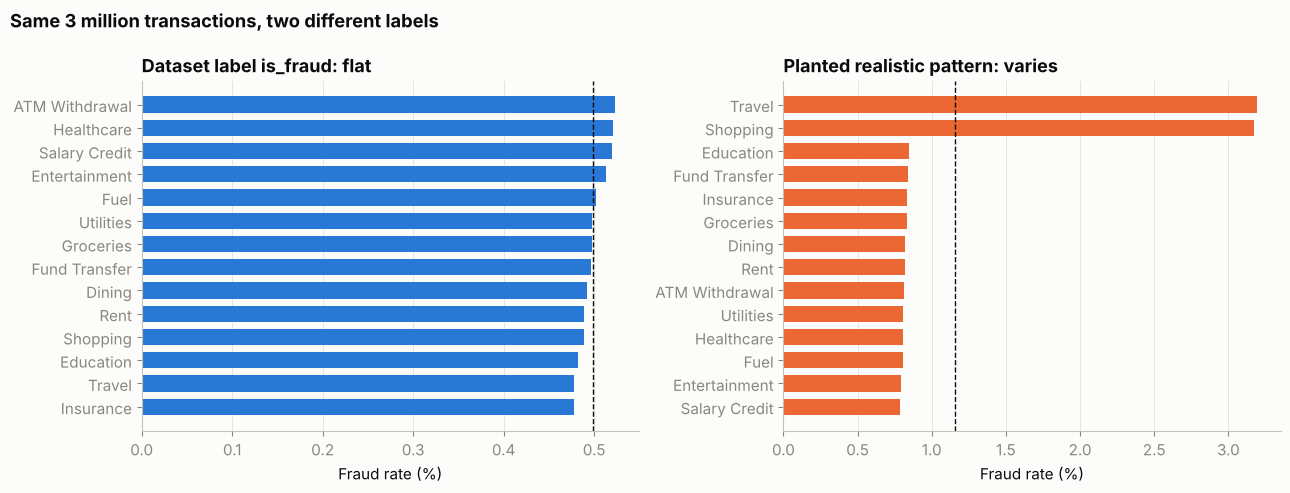

⚠️ [Signal] is_fraud by merchant_category: Cramer's V 0.002, p=0.41  |  rate ranges 0.48% to 0.52% (spread 0.05%).


⚠️ [Signal] is_fraud by card_type: Cramer's V 0.001, p=0.36  |  rate ranges 0.48% to 0.51% (spread 0.03%).


✅ [Signal] planted_fraud by merchant_category: Cramer's V 0.077, p=0  |  rate ranges 0.78% to 3.19% (spread 2.41%).


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, col, title, colour in [(axes[0], "is_fraud", "Dataset label is_fraud: flat", BLUE),
                               (axes[1], "planted_fraud", "Planted realistic pattern: varies", ORANGE)]:
    rates = fraud.groupby("merchant_category")[col].mean().sort_values()
    ax.barh(rates.index, rates.values * 100, color=colour, height=0.7)
    ax.axvline(fraud[col].mean() * 100, color=INK, ls="--", lw=1)
    ax.set_title(title); ax.set_xlabel("Fraud rate (%)")
    ax.grid(axis="y", visible=False)
plt.suptitle("Same 3 million transactions, two different labels", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

# Statistical version of the same idea (chi-square test + effect size)
for col in ["merchant_category", "card_type"]:
    ld.label_spread(fraud, "is_fraud", col)
_ = controls.label_spread(fraud, "planted_fraud", "merchant_category")

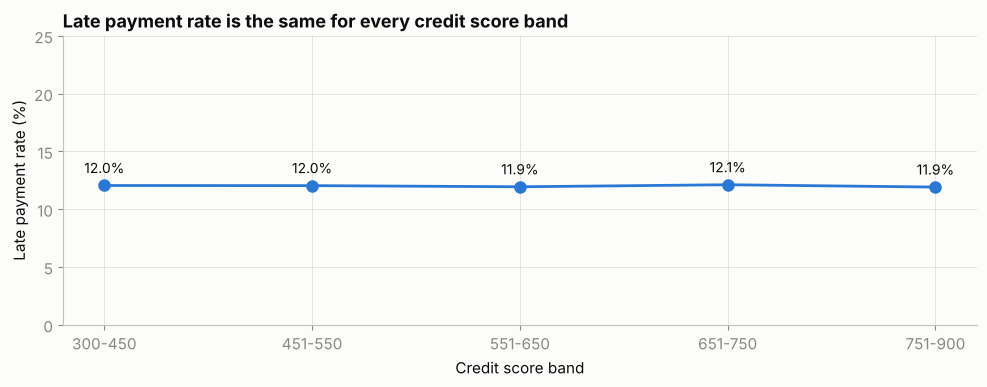

⚠️ [Signal] late_payment_flag by credit_score_band: Cramer's V 0.002, p=0.54  |  rate ranges 11.91% to 12.11% (spread 0.20%).
⚠️ [Signal] late_payment_flag by loan_type: Cramer's V 0.004, p=0.14  |  rate ranges 11.85% to 12.19% (spread 0.34%).


In [10]:
# Late payments: in real lending, lower credit scores pay late far more often
pay["credit_score_band"] = pd.cut(pay["credit_score"], [299, 450, 550, 650, 750, 900],
                                  labels=["300-450", "451-550", "551-650", "651-750", "751-900"])
band = pay.groupby("credit_score_band", observed=True)["late_payment_flag"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(band.index.astype(str), band.values, marker="o", color=BLUE, lw=2, ms=8)
for x, y in zip(band.index.astype(str), band.values):
    ax.annotate(f"{y:.1f}%", (x, y), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=10)
ax.set_ylim(0, 25); ax.set_ylabel("Late payment rate (%)"); ax.set_xlabel("Credit score band")
ax.set_title("Late payment rate is the same for every credit score band")
plt.tight_layout(); plt.show()

ld.label_spread(pay, "late_payment_flag", "credit_score_band")
_ = ld.label_spread(pay, "late_payment_flag", "loan_type")

## 5. Check 2: Do the tables link together correctly?

In a relational database, every ID should point to a record that exists, and linked records should agree with each other. For example, a card belongs to a customer **and** to an account, so the account should belong to that same customer.

In [11]:
ld.foreign_key(ac, "customer_id", cu, name="Accounts -> customers exist")
ld.foreign_key(ca, "account_id", ac, name="Cards -> accounts exist")
ld.foreign_key(ct, "card_id", ca, name="Card transactions -> cards exist")
ld.foreign_key(tx, "account_id", ac, name="Transactions -> accounts exist")
ld.foreign_key(lp, "loan_id", lo, name="Loan payments -> loans exist")

card_acct = ca.merge(ac[["account_id", "customer_id"]], on="account_id", suffixes=("", "_of_account"))
ld.agreement("Card owner = owner of its linked account",
             card_acct["customer_id"], card_acct["customer_id_of_account"],
             "a card is linked to an account that belongs to someone else.")
_ = ld.duplicates(ct.drop(columns="card_txn_id"), name="Duplicate card transactions")

✅ [Integrity] Accounts -> customers exist: 0.00% orphans  |  every ID points to a real record.
✅ [Integrity] Cards -> accounts exist: 0.00% orphans  |  every ID points to a real record.
✅ [Integrity] Card transactions -> cards exist: 0.00% orphans  |  every ID points to a real record.
✅ [Integrity] Transactions -> accounts exist: 0.00% orphans  |  every ID points to a real record.
✅ [Integrity] Loan payments -> loans exist: 0.00% orphans  |  every ID points to a real record.
❌ [Integrity] Card owner = owner of its linked account: >99.99% mismatched  |  a card is linked to an account that belongs to someone else.


✅ [Integrity] Duplicate card transactions: 0.00% duplicated  |  no repeated rows.


## 6. Check 3: Does time make sense?

Money cannot move through an account before it is opened, and a loan cannot be repaid before it starts.

In [12]:
t = tx.merge(ac[["account_id", "open_date"]], on="account_id")
ld.date_order("Transaction after account opened", t["open_date"], t["txn_date"],
              "money moves through accounts that do not exist yet.")

c = ct.merge(ca[["card_id", "issue_date", "expiry_date"]], on="card_id")
ld.date_order("Card used after it was issued", c["issue_date"], c["txn_date"],
              "cards are used before they were issued.")
ld.date_order("Card used before it expired", c["txn_date"], c["expiry_date"],
              "cards are used after they expired.")

p = lp.merge(lo[["loan_id", "start_date"]], on="loan_id")
ld.date_order("Loan payment after loan started", p["start_date"], p["payment_date"],
              "loans are repaid before they begin.")

a = ac.merge(br[["branch_id", "opened_date"]], on="branch_id")
ld.date_order("Account opened after its branch opened", a["opened_date"], a["open_date"],
              "accounts open at branches that do not exist yet.")

_ = ld.date_order("Support ticket resolved after it was opened", st["date_opened"], st["date_resolved"])

❌ [Time] Transaction after account opened: 19.42% impossible  |  money moves through accounts that do not exist yet.


❌ [Time] Card used after it was issued: 31.03% impossible  |  cards are used before they were issued.
❌ [Time] Card used before it expired: 23.90% impossible  |  cards are used after they expired.
❌ [Time] Loan payment after loan started: 46.71% impossible  |  loans are repaid before they begin.
❌ [Time] Account opened after its branch opened: 18.51% impossible  |  accounts open at branches that do not exist yet.


✅ [Time] Support ticket resolved after it was opened: 0.00% impossible  |  events happen in a possible order.


## 7. Check 4: Do real-world rules and relationships hold?

**Rules** are things that should never happen. **Relationships** are patterns you would expect in real banking data (they get a softer WARN, because real data can surprise you).

In [13]:
age_at_join = (cu["join_date"] - cu["date_of_birth"]).dt.days / 365.25
ld.rule("Customers are adults when they join", age_at_join < 18, "customers joined the bank as children.")

is_debit = ca["card_type"].eq("Debit")
ld.rule("Debit cards have no credit limit", is_debit & (ca["credit_limit"] > 0),
        "debit cards carry a credit limit (only credit cards should).")
ld.rule("Credit cards have a credit limit", ~is_debit & (ca["credit_limit"] <= 0),
        "credit cards with a limit of zero.")

pay_count = lp.groupby("loan_id").size().reindex(lo["loan_id"]).fillna(0).values
ld.rule("Loan has no more payments than its term", pay_count > lo["term_months"].values,
        "loans with more monthly payments than months in the term.")

days_to_resolve = (st["date_resolved"] - st["date_opened"]).dt.days
lc = lo.merge(cu, on="customer_id")
ld.expected_relationship("Higher credit score -> lower interest rate",
                         lc["credit_score"], lc["interest_rate"], direction="negative")
ld.expected_relationship("Higher income -> higher credit score", cu["annual_income"], cu["credit_score"])
ld.expected_relationship("Higher income -> bigger loans", lc["annual_income"], lc["loan_amount"])
_ = ld.expected_relationship("Slower ticket resolution -> lower satisfaction",
                             days_to_resolve, st["satisfaction_score"], direction="negative")

❌ [Plausibility] Customers are adults when they join: 14.02% break the rule  |  customers joined the bank as children.
❌ [Plausibility] Debit cards have no credit limit: 24.68% break the rule  |  debit cards carry a credit limit (only credit cards should).
❌ [Plausibility] Credit cards have a credit limit: 24.65% break the rule  |  credit cards with a limit of zero.
❌ [Plausibility] Loan has no more payments than its term: 21.79% break the rule  |  loans with more monthly payments than months in the term.
⚠️ [Plausibility] Higher credit score -> lower interest rate: Spearman +0.000  |  expected a negative relationship.
⚠️ [Plausibility] Higher income -> higher credit score: Spearman +0.002  |  expected a positive relationship.
⚠️ [Plausibility] Higher income -> bigger loans: Spearman -0.001  |  expected a positive relationship.
⚠️ [Plausibility] Slower ticket resolution -> lower satisfaction: Spearman -0.000  |  expected a negative relationship.


## 8. The verdict

In [14]:
print(ld.summary())
print(controls.summary())
display(ld.report())

Banking Transactions Dataset: Trust Score 35/100 (Not suitable for ML as-is) | 7 pass, 8 warn, 13 fail
Positive controls: Trust Score 100/100 (Trustworthy for ML) | 3 pass, 0 warn, 0 fail


,group,check,result,metric,detail
0,Signal,Label signal: Card fraud,❌ FAIL,AUC 0.513 vs shuffled 0.498,"no better than shuffled labels, so the labels look like noise (13 features, 200,000 rows)."
1,Signal,Label signal: Late payment,❌ FAIL,AUC 0.499 vs shuffled 0.499,"no better than shuffled labels, so the labels look like noise (8 features, 200,000 rows)."
2,Signal,Label signal: Loan default,❌ FAIL,AUC 0.516 vs shuffled 0.494,"no better than shuffled labels, so the labels look like noise (8 features, 22,000 rows)."
3,Signal,is_fraud by merchant_category,⚠️ WARN,"Cramer's V 0.002, p=0.41",rate ranges 0.48% to 0.52% (spread 0.05%).
4,Signal,is_fraud by card_type,⚠️ WARN,"Cramer's V 0.001, p=0.36",rate ranges 0.48% to 0.51% (spread 0.03%).
5,Signal,late_payment_flag by credit_score_band,⚠️ WARN,"Cramer's V 0.002, p=0.54",rate ranges 11.91% to 12.11% (spread 0.20%).
6,Signal,late_payment_flag by loan_type,⚠️ WARN,"Cramer's V 0.004, p=0.14",rate ranges 11.85% to 12.19% (spread 0.34%).
7,Integrity,Accounts -> customers exist,✅ PASS,0.00% orphans,every ID points to a real record.
8,Integrity,Cards -> accounts exist,✅ PASS,0.00% orphans,every ID points to a real record.
9,Integrity,Card transactions -> cards exist,✅ PASS,0.00% orphans,every ID points to a real record.


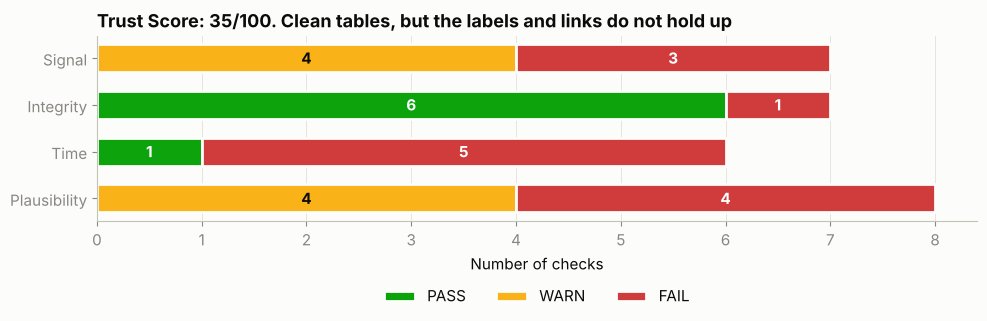

In [15]:
rep = pd.DataFrame([vars(f) for f in ld.findings])
counts = rep.groupby(["group", "status"]).size().unstack(fill_value=0).reindex(columns=[PASS, WARN, FAIL], fill_value=0)
counts = counts.reindex(["Signal", "Integrity", "Time", "Plausibility"])

fig, ax = plt.subplots(figsize=(10, 3.6))
left = np.zeros(len(counts))
for status in [PASS, WARN, FAIL]:
    ax.barh(counts.index, counts[status], left=left, color=STATUS[status], height=0.6,
            label=status, edgecolor=SURFACE, linewidth=2)
    for i, (l, v) in enumerate(zip(left, counts[status])):
        if v:
            ax.text(l + v / 2, i, str(v), ha="center", va="center", fontweight="bold",
                    color=INK if status == WARN else "white")
    left += counts[status].values
ax.invert_yaxis(); ax.set_xlabel("Number of checks"); ax.grid(axis="y", visible=False)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.28), frameon=False)
ax.set_title(f"Trust Score: {ld.trust_score():.0f}/100. Clean tables, but the labels and links do not hold up")
plt.tight_layout(); plt.show()

## 9. What this means

**What the dataset is good for ✅**
- Practising SQL joins, aggregations and window functions on a realistic 10-table schema
- Building Power BI or Tableau dashboards at scale (5.9M rows, zero missing values)
- Practising data engineering: loading, indexing, partitioning

**What it cannot support ❌**
- Fraud detection, late payment or default prediction models. The labels behave like coin flips, so any model will score around AUC 0.5.
- Any "insight" that connects tables (for example, *customers with low credit scores default more*). The relationships were not generated, so such findings would be artefacts.

**A warning sign to watch for:** if you see a notebook on a dataset like this reporting **99% accuracy on fraud**, check the class balance. With 0.5% fraud, a model that always says *"not fraud"* scores 99.5% accuracy while learning nothing. Use ROC AUC, PR AUC or recall instead.

**What a fix would look like:** generate the data so that labels depend on behaviour (spending spikes, repeat transactions, credit score) and linked tables share the same owners and dates. The *planted pattern* in Section 4 is a tiny example of exactly that.

## 10. Use it on your own data

Copy `lie_detector.py` (it is written to this notebook's output, and on GitHub), then:

```python
from lie_detector import LieDetector

ld = LieDetector("My dataset")
ld.label_signal(df, target="churn")                           # 1. Is there signal?
ld.foreign_key(orders, "customer_id", customers)              # 2. Do tables link?
ld.date_order("Shipped after ordered", df.order_date, df.ship_date)  # 3. Does time make sense?
ld.rule("No negative prices", df.price < 0)                    # 4. Do rules hold?
print(ld.summary()); ld.report()
```

**Fork this notebook**, swap in your own dataset, and run it before you build your next model.

---

If this saved you a few hours, an **upvote** helps other people find it before they spend a weekend modelling noise. ⭐ the repo on [GitHub](https://github.com/CollinsLemeke/dataset-lie-detector) if you want to follow updates. Questions and ideas for new checks are welcome in the comments.